# Modularidad

Utilizaremos la función greedy_modularity_comunities de NetworkX: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.modularity_max.greedy_modularity_communities.html

In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

from networkx.algorithms.community import greedy_modularity_communities 

## GOT

In [2]:
G=nx.Graph()

In [3]:
stark_targaryen = ['Rickard','Lyarra','Aerys','Rhaella','Catelyn','Ned','Lyanna','Rhaegar','Elia','Viserys','Daenerys',
                   'Brandon', 'Benjen', 'Robb', 'Sansa', 'Arya', 'Bran', 'Rickon', 'Rhaenys', 'Aegon','Jon']

parents = [('Rickard','Ned'),('Rickard','Lyanna'),('Rickard','Brandon'),('Rickard','Benjen'),
           ('Lyarra','Ned'),('Lyarra','Lyanna'),('Lyarra','Brandon'),('Lyarra','Benjen'),
           ('Aerys','Rhaegar'),('Aerys','Viserys'),('Aerys','Daenerys'),
           ('Rhaella','Rhaegar'),('Rhaella','Viserys'),('Rhaella','Daenerys'),
           ('Catelyn','Robb'),('Catelyn','Sansa'), ('Catelyn','Arya'), ('Catelyn','Bran'), ('Catelyn','Rickon'),
           ('Ned','Robb'),('Ned','Sansa'), ('Ned','Arya'), ('Ned','Bran'), ('Ned','Rickon'),
           ('Rhaegar','Rhaenys'), ('Rhaegar','Aegon'),('Elia','Rhaenys'), ('Elia','Aegon'),
           ('Lyanna','Jon'),('Rhaegar','Jon')]

G.add_nodes_from(stark_targaryen)
G.add_edges_from(parents)

Al implementar la función, nos arroja una lista de objetos (conjuntos) en donde se agrupan los nodos.

In [4]:
comunidades = greedy_modularity_communities(G)
comunidades

[frozenset({'Aegon',
            'Aerys',
            'Daenerys',
            'Elia',
            'Rhaegar',
            'Rhaella',
            'Rhaenys',
            'Viserys'}),
 frozenset({'Arya', 'Bran', 'Catelyn', 'Ned', 'Rickon', 'Robb', 'Sansa'}),
 frozenset({'Benjen', 'Brandon', 'Jon', 'Lyanna', 'Lyarra', 'Rickard'})]

Vamos a crear un diccionario en el que cada nodo está asignado a su comunidad, para la visualización.

In [5]:
diccionario = {}

for i, comunidad in enumerate(comunidades): #visita cada comunidad
  for nodo in comunidad: #visita cada nodo de la comunidad
    diccionario[nodo] = i 
    
diccionario

{'Rhaenys': 0,
 'Viserys': 0,
 'Aegon': 0,
 'Elia': 0,
 'Rhaegar': 0,
 'Rhaella': 0,
 'Aerys': 0,
 'Daenerys': 0,
 'Catelyn': 1,
 'Arya': 1,
 'Rickon': 1,
 'Robb': 1,
 'Ned': 1,
 'Bran': 1,
 'Sansa': 1,
 'Lyarra': 2,
 'Benjen': 2,
 'Brandon': 2,
 'Jon': 2,
 'Lyanna': 2,
 'Rickard': 2}

In [6]:
colors = np.array([diccionario[i] for i in G ])

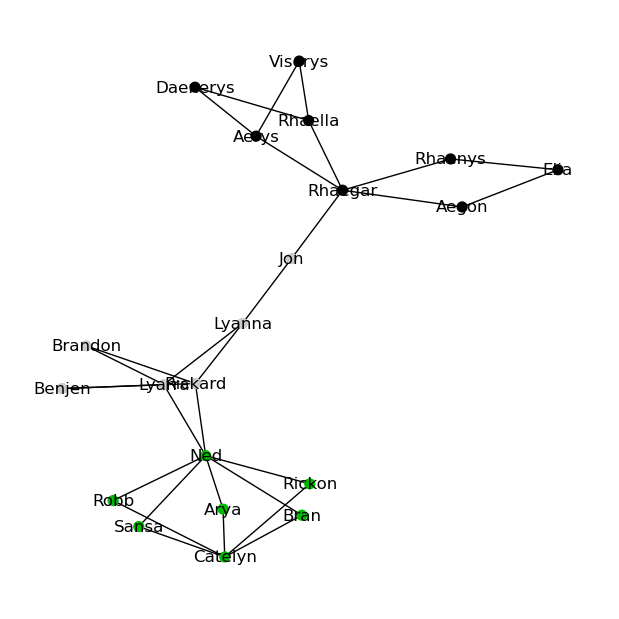

In [7]:
plt.figure(figsize = [6,6])

nx.draw_kamada_kawai(G, node_color = colors, node_size = 50,
                     cmap = 'nipy_spectral',  with_labels=True)

Usamos un mapa de color que haga contraste entre las comunidades. Podemos ver 3 comunidades bien determinadas, que serían tres familias, en este caso.

Podemos calcular la modularidad: https://networkx.org/documentation/stable/reference/algorithms/generated/networkx.algorithms.community.quality.modularity.html

In [8]:
nx.algorithms.community.modularity(G, comunidades)

0.5627777777777777

Recordemos que la modularidad es un valor entre 0 y 1. Una modularidad mayor a 0.3 se considera alta.

## Colaboración académica

Ahora hagamos el ejercicio con una red de colaboración académica (los nodos están unidos si los investigadores son coautores de artículos científicos).

In [9]:
datos = pd.read_csv('data/ca-netscience.mtx', skiprows = 2, header = None,sep = ' ',
            #usecols = [0,1]
            )
datos

,0,1
0,2,1
1,3,1
2,4,1
3,5,1
4,16,1
...,...,...
909,374,373
910,376,375
911,377,375
912,377,376


In [10]:
G = nx.from_pandas_edgelist(datos, source = 0, target = 1)

In [11]:
comunidades = greedy_modularity_communities(G)

In [12]:
comunidades

[frozenset({21,
            22,
            23,
            24,
            30,
            31,
            32,
            33,
            34,
            35,
            36,
            41,
            42,
            43,
            50,
            51,
            52,
            53,
            54,
            55,
            76,
            109,
            167,
            168,
            169,
            170,
            205,
            216,
            217,
            218,
            219,
            220,
            221,
            227,
            228,
            232,
            233,
            241,
            242,
            243,
            244,
            266,
            267,
            268,
            275,
            276,
            277,
            287,
            288,
            289,
            290,
            291,
            292,
            307,
            336,
            364,
            369,
            370}),
 frozenset({25,
            26,
 

In [13]:
diccionario = {}

for i, comunidad in enumerate(comunidades): #visita cada comunidad
  for nodo in comunidad: #visita cada nodo de la comunidad
    diccionario[nodo] = i 
    
diccionario

{266: 0,
 267: 0,
 268: 0,
 275: 0,
 276: 0,
 277: 0,
 21: 0,
 22: 0,
 23: 0,
 24: 0,
 30: 0,
 287: 0,
 288: 0,
 31: 0,
 32: 0,
 33: 0,
 289: 0,
 35: 0,
 34: 0,
 36: 0,
 290: 0,
 41: 0,
 292: 0,
 291: 0,
 43: 0,
 167: 0,
 168: 0,
 169: 0,
 42: 0,
 170: 0,
 50: 0,
 307: 0,
 51: 0,
 52: 0,
 53: 0,
 55: 0,
 54: 0,
 76: 0,
 205: 0,
 336: 0,
 216: 0,
 217: 0,
 218: 0,
 219: 0,
 220: 0,
 221: 0,
 227: 0,
 228: 0,
 232: 0,
 233: 0,
 364: 0,
 109: 0,
 241: 0,
 242: 0,
 243: 0,
 244: 0,
 369: 0,
 370: 0,
 256: 1,
 257: 1,
 273: 1,
 25: 1,
 282: 1,
 26: 1,
 283: 1,
 284: 1,
 155: 1,
 156: 1,
 157: 1,
 158: 1,
 27: 1,
 28: 1,
 39: 1,
 295: 1,
 40: 1,
 296: 1,
 297: 1,
 173: 1,
 174: 1,
 175: 1,
 306: 1,
 315: 1,
 316: 1,
 317: 1,
 197: 1,
 198: 1,
 326: 1,
 231: 1,
 104: 1,
 105: 1,
 234: 1,
 235: 1,
 106: 1,
 236: 1,
 237: 1,
 238: 1,
 239: 1,
 240: 1,
 107: 1,
 108: 1,
 372: 1,
 246: 1,
 247: 1,
 251: 1,
 124: 1,
 125: 1,
 255: 1,
 9: 2,
 10: 2,
 11: 2,
 12: 2,
 285: 2,
 303: 2,
 67: 2,
 68: 2,

In [14]:
colors = np.array([diccionario[i] for i in G ])

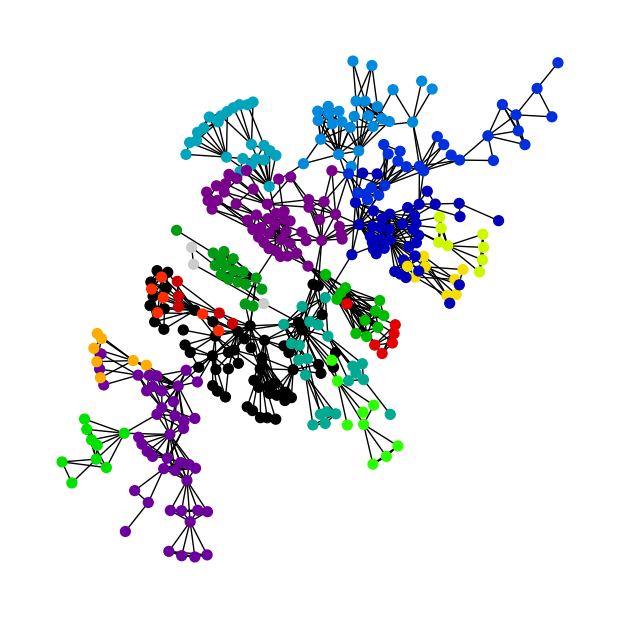

In [15]:
plt.figure(figsize = [6,6])

nx.draw_kamada_kawai(G, node_color = colors, node_size = 50,
                     cmap = 'nipy_spectral')

En este caso, se podría investigar a qué se deben las comunidades, podrían ser investigadores de la misma universidad, por ejemplo. Eso depende de los atributos de los nodos.

In [16]:
nx.algorithms.community.modularity(G, comunidades)

0.8386393997577197

En este caso, la modularidad es muy alta.